# Linear time series analysis

This notebook demonstrates the linear-analysis tools in `nolitisea.linear`:

| Module | Function | Purpose |
|---|---|---|
| `nolitisea.linear.spectrum` | `power_spectrum` | FFT-based power spectrum (periodogram, Welch, raw FFT) |
| `nolitisea.linear.mem_spec` | `mem_spectrum` | Maximum-entropy (Burg AR-based) spectrum |
| `nolitisea.linear.autocorr` | `autocorrelation` | Autocorrelation function (Wiener-Khinchin FFT) |
| `nolitisea.linear.ar_model` | `fit_ar_model`, `iterate_ar_model` | Multivariate AR fitting and noise-driven iteration |
| `nolitisea.linear.arima_model` | `difference`, `fit_arima`, `iterate_arima_model` | Differencing, ARIMA/ARMA fitting (Hannan-Rissanen refinement), bootstrap iteration |
| `nolitisea.linear.filters` | `notch_filter`, `wiener_filter`, `low121`, `savitzky_golay` | Notch, frequency-domain Wiener, 1-2-1 low-pass, Savitzky-Golay filters |

A synthetic signal (two sinusoids in white noise) is used so the results are
easy to verify; a chaotic Lorenz series is shown for contrast at the end.

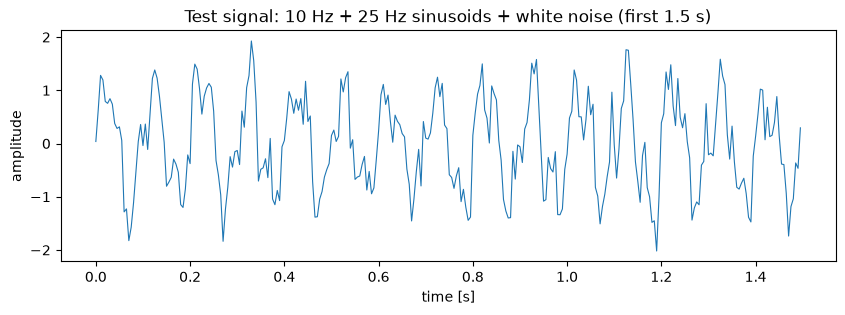

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

from nolitisea.generate.lorenz import lorenz
from nolitisea.linear.ar_model import fit_ar_model, iterate_ar_model
from nolitisea.linear.arima_model import difference, fit_arima, iterate_arima_model
from nolitisea.linear.autocorr import autocorrelation
from nolitisea.linear.filters import (
    low121,
    notch_filter,
    savitzky_golay,
    wiener_filter,
)
from nolitisea.linear.mem_spec import mem_spectrum
from nolitisea.linear.spectrum import power_spectrum

# ------------------------------------------------------------------
# Test signal: two sinusoids (10 Hz and 25 Hz) in white noise,
# sampled at fs = 200 Hz for 4096 samples (~20.5 s).
# ------------------------------------------------------------------
rng = np.random.default_rng(0)
fs = 200.0        # sampling frequency (Hz)
N = 4096
t = np.arange(N) / fs
x = (1.0 * np.sin(2 * np.pi * 10.0 * t)
     + 0.5 * np.sin(2 * np.pi * 25.0 * t)
     + 0.3 * rng.standard_normal(N))

# Pure white noise and a chaotic Lorenz series are used later for contrast.
white = rng.standard_normal(N)
_, lor = lorenz(length=N)
lorenz_x = lor[:, 0]

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t[:300], x[:300], lw=0.8)
ax.set(xlabel="time [s]", ylabel="amplitude",
       title="Test signal: 10 Hz + 25 Hz sinusoids + white noise (first 1.5 s)")
plt.show()

## 1. `power_spectrum` — FFT-based power spectrum

`power_spectrum(x, method=..., fs=...)` returns `(freq, psd)`:

- `method="welch"` (default): averaged, overlapping segments — smooth, low variance;
- `method="periodogram"`: a single FFT over the whole record — highest resolution, noisy;
- `method="fft"`: raw one-sided FFT periodogram, no segment averaging.

Useful options: `fs` (sampling frequency; frequencies are returned in Hz),
`nperseg` / `noverlap` (Welch segment length and overlap), `detrend`
(`"constant"` mean removal by default, `"linear"`, or `False`), and
`scaling` (`"density"` for the PSD vs `"spectrum"` for plain power).

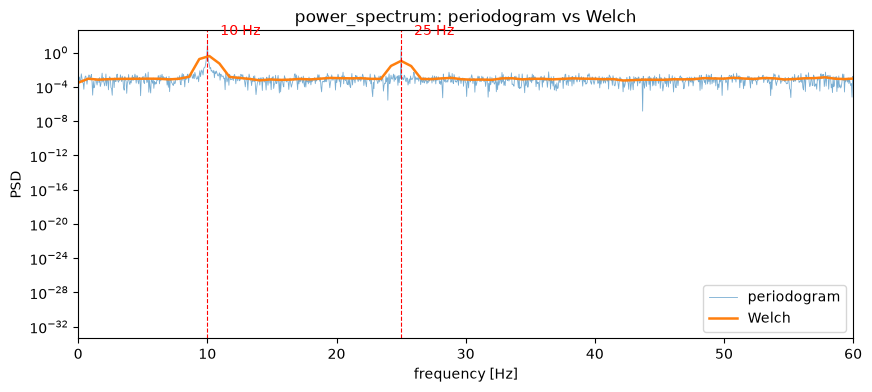

Welch peak frequencies [Hz]: [10.16 25.  ]


In [2]:
f_welch, psd_welch = power_spectrum(x, method="welch", fs=fs)
f_per, psd_per = power_spectrum(x, method="periodogram", fs=fs)

fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(f_per, psd_per, lw=0.6, alpha=0.6, label="periodogram")
ax.semilogy(f_welch, psd_welch, lw=1.8, label="Welch")
for f0 in (10.0, 25.0):
    ax.axvline(f0, color="red", ls="--", lw=0.8)
    ax.text(f0 + 1.0, ax.get_ylim()[1] * 0.3, f"{f0:g} Hz", color="red")
ax.set(xlabel="frequency [Hz]", ylabel="PSD", xlim=(0, 60),
       title="power_spectrum: periodogram vs Welch")
ax.legend()
plt.show()

# The dominant peaks of the (smooth) Welch estimate recover the
# two sinusoid frequencies (local maxima, not just the two top bins,
# which can both fall on the broad 10 Hz peak).
peaks, _ = find_peaks(psd_welch, prominence=0.05 * psd_welch.max())
top = peaks[np.argsort(psd_welch[peaks])[-2:]]
print("Welch peak frequencies [Hz]:", np.round(np.sort(f_welch[top]), 2))

The periodogram resolves the two sinusoid frequencies sharply but is very
noisy. Welch averaging trades frequency resolution for a much smoother,
lower-variance estimate.

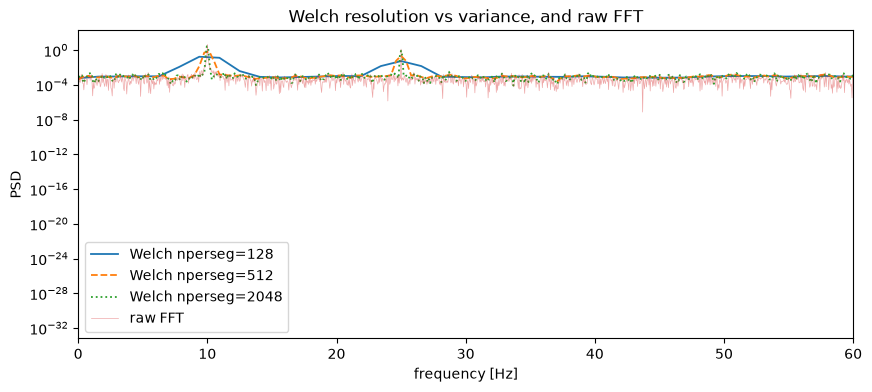

frequency resolution [Hz]: raw FFT 0.049 | Welch nperseg=128 1.562 | Welch nperseg=2048 0.098


In [3]:
# Welch segment length trades frequency resolution for variance reduction.
fig, ax = plt.subplots(figsize=(10, 4))
for nperseg, ls in [(128, "-"), (512, "--"), (2048, ":")]:
    f_seg, psd_seg = power_spectrum(x, method="welch", fs=fs, nperseg=nperseg)
    ax.semilogy(f_seg, psd_seg, ls, lw=1.3, label=f"Welch nperseg={nperseg}")

# method="fft": raw one-sided FFT over the whole record, no averaging.
f_fft, psd_fft = power_spectrum(x, method="fft", fs=fs)
ax.semilogy(f_fft, psd_fft, lw=0.5, alpha=0.4, label="raw FFT")

ax.set(xlabel="frequency [Hz]", ylabel="PSD", xlim=(0, 60),
       title="Welch resolution vs variance, and raw FFT")
ax.legend()
plt.show()

f128, _ = power_spectrum(x, method="welch", fs=fs, nperseg=128)
f2048, _ = power_spectrum(x, method="welch", fs=fs, nperseg=2048)
print(f"frequency resolution [Hz]: raw FFT {f_fft[1]:.3f} | Welch nperseg=128 {f128[1]:.3f} | "
      f"Welch nperseg=2048 {f2048[1]:.3f}")

## 2. `mem_spectrum` — maximum-entropy (AR) spectrum

`mem_spectrum(series, order, n_freq=512)` fits an autoregressive model to the
series with Burg's method and evaluates the AR spectral density at `n_freq`
points. It returns `(freqs, power)` where **freqs are normalised to cycles per
sample in [0, 0.5)** — multiply by the sampling rate `fs` to obtain an Hz axis
comparable with `power_spectrum`.

The MEM estimate is smooth like Welch but can resolve narrow peaks even from
short records. The AR `order` is the key tuning parameter: too low blurs peaks
together, too high invents spurious structure. (Note: the absolute power scale
of the MEM estimate follows the convention and is not directly
comparable to the Welch PSD; shapes and peak locations are what matters.)

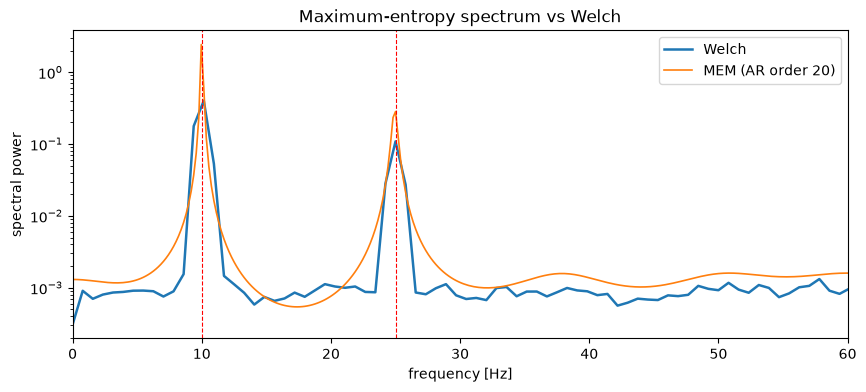

MEM dominant peak [Hz]: 9.96


In [4]:
order = 20
f_mem_norm, p_mem = mem_spectrum(x, order=order, n_freq=512)
f_mem = f_mem_norm * fs          # cycles/sample -> Hz

fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(f_welch, psd_welch, lw=1.8, label="Welch")
ax.semilogy(f_mem, p_mem, lw=1.2, label=f"MEM (AR order {order})")
for f0 in (10.0, 25.0):
    ax.axvline(f0, color="red", ls="--", lw=0.8)
ax.set(xlabel="frequency [Hz]", ylabel="spectral power", xlim=(0, 60),
       title="Maximum-entropy spectrum vs Welch")
ax.legend()
plt.show()

print("MEM dominant peak [Hz]:", round(float(f_mem[np.argmax(p_mem)]), 2))

### Choice of the AR order

Order 4 is too small and merges the two peaks; order 20 resolves both
cleanly; order 64 starts to add spurious fine structure.

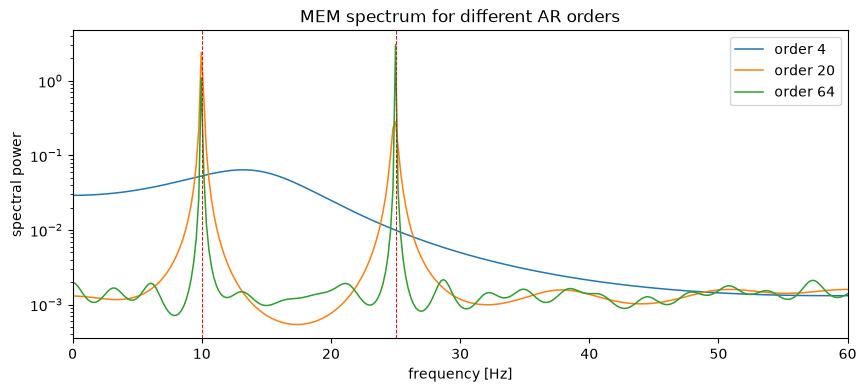

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
for ar_order in (4, 20, 64):
    fn, pn = mem_spectrum(x, order=ar_order, n_freq=512)
    ax.semilogy(fn * fs, pn, lw=1.1, label=f"order {ar_order}")
for f0 in (10.0, 25.0):
    ax.axvline(f0, color="red", ls="--", lw=0.7)
ax.set(xlabel="frequency [Hz]", ylabel="spectral power", xlim=(0, 60),
       title="MEM spectrum for different AR orders")
ax.legend()
plt.show()

## 3. `autocorrelation` — autocorrelation function

`autocorrelation(x, max_lag=None, norm=True, detrend=True)` computes the ACF
via the Wiener-Khinchin theorem (FFT of the power spectrum):

- `max_lag`: return lags `0 .. max_lag` (default: `N - 1`, the full meaningful range);
- `norm=True`: normalise so that `r(0) = 1`;
- `detrend=True`: subtract the mean first, so that uncorrelated data has
  `r(lag) ≈ 0` for every nonzero lag.

For a periodic signal the ACF oscillates at the signal period; for white
noise it vanishes for all nonzero lags.

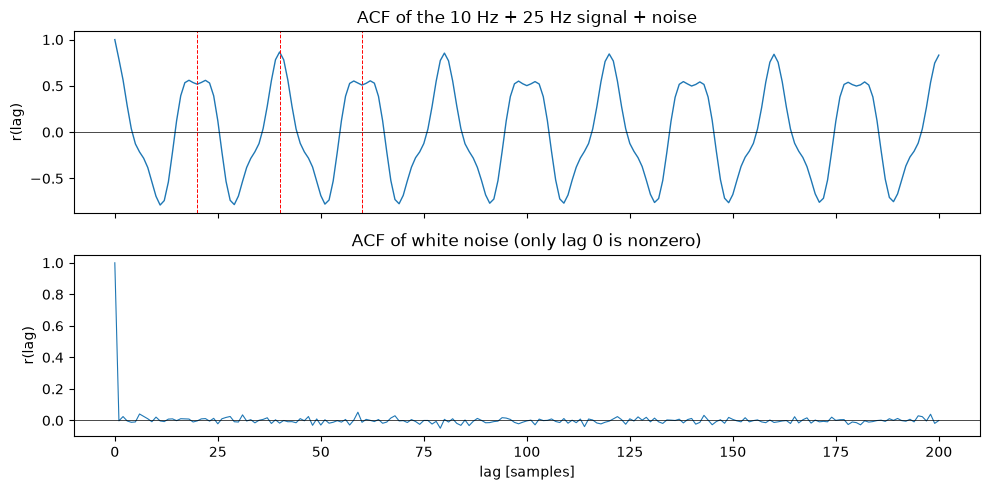

normalised r(0) = 1.000
max |r(lag)| for lag >= 1 of white noise = 0.052


In [6]:
max_lag = 200
r_x = autocorrelation(x, max_lag=max_lag)
r_w = autocorrelation(white, max_lag=max_lag)

lags = np.arange(max_lag + 1)
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(lags, r_x, lw=1.0)
axes[0].axhline(0, color="k", lw=0.5)
# The dominant 10 Hz component makes the ACF oscillate with a period of
# fs / 10 Hz = 20 samples; the 25 Hz component adds the finer wiggles.
for lag in (20, 40, 60):
    axes[0].axvline(lag, color="red", ls="--", lw=0.7)
axes[0].set(title="ACF of the 10 Hz + 25 Hz signal + noise", ylabel="r(lag)")

axes[1].plot(lags, r_w, lw=0.8)
axes[1].axhline(0, color="k", lw=0.5)
axes[1].set(title="ACF of white noise (only lag 0 is nonzero)",
            xlabel="lag [samples]", ylabel="r(lag)")
plt.tight_layout()
plt.show()

print(f"normalised r(0) = {r_x[0]:.3f}")
print(f"max |r(lag)| for lag >= 1 of white noise = {np.abs(r_w[1:]).max():.3f}")

unnormalised r(0) = 2916.465  (N * variance = 2916.465)
detrend=True : r(49) = -0.530
detrend=False: r(49) =  0.946   (the offset dominates)


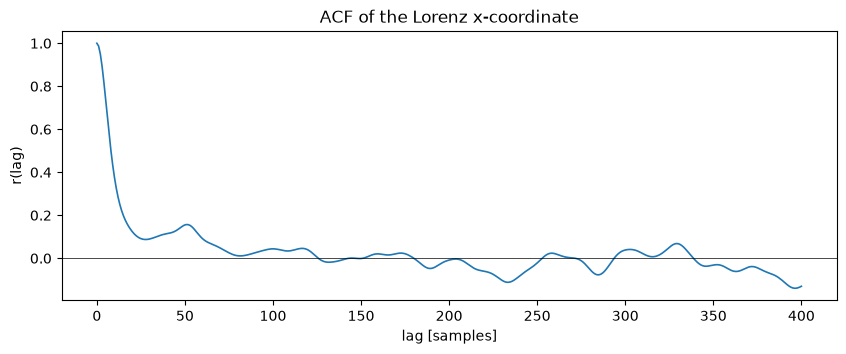

In [7]:
# Option demos:
#  * norm=False keeps the raw scale: r(0) is the sum of squared samples,
#    i.e. N * variance after detrending;
#  * detrend=False leaves the mean in, and an offset leaks into every lag.
r_raw = autocorrelation(x, max_lag=50, norm=False, detrend=True)
print(f"unnormalised r(0) = {r_raw[0]:.3f}  (N * variance = {N * x.var():.3f})")

x_offset = x + 5.0                       # signal with a non-zero mean
r_det = autocorrelation(x_offset, max_lag=50, detrend=True)
r_nodet = autocorrelation(x_offset, max_lag=50, detrend=False)
print(f"detrend=True : r(49) = {r_det[49]: .3f}")
print(f"detrend=False: r(49) = {r_nodet[49]: .3f}   (the offset dominates)")

# Chaotic Lorenz data: the ACF decays smoothly towards zero -- typical for a
# broadband nonlinear signal, in contrast to the oscillating sinusoid ACF.
r_lor = autocorrelation(lorenz_x, max_lag=400)
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(r_lor, lw=1.2)
ax.axhline(0, color="k", lw=0.5)
ax.set(xlabel="lag [samples]", ylabel="r(lag)",
       title="ACF of the Lorenz x-coordinate")
plt.show()

## 4. `fit_ar_model` / `iterate_ar_model` — autoregressive modelling

`fit_ar_model(series, order)` fits a **multivariate** AR model by ordinary
least squares:

    y_d(t) = sum_i sum_j coeffs[d, i, j] * y_i(t - 1 - j) + residual_d(t)

It returns a dict with:

- `coeffs` — coefficient tensor of shape `(dim, dim, order)`;
  `coeffs[d, i, j]` multiplies `y_i(t-1-j)` in the equation for `y_d(t)`;
- `residuals` — one-step prediction errors, shape `(N - order, dim)`;
- `forecast_errors` — residual RMS per component (the "individual
  forecast errors");
- `average_forecast_error` — RMS of the forecast errors across components;
- `mean` — the subtracted per-component mean.

`iterate_ar_model(coeffs, sigma, n_steps, seed=...)` re-synthesises data from
a fitted model, driving it with Gaussian noise of standard deviation `sigma`
(typically the fitted `forecast_errors`).  The raw output and the `initial`
history are in **mean-subtracted units**; pass `mean=fit["mean"]` (and an
`initial` history taken from `series - fit["mean"]`) to obtain output in the
original series units.  `sigma=0` gives the deterministic, noise-free
forecast (the conditional expectation), which decays geometrically towards
the mean for a stable model.


order  avg. forecast error      R^2
    1             1.271191   0.9740
    2             0.378556   0.9977
    4             0.079369   0.9999
    8             0.039023   1.0000
   16             0.038217   1.0000

AR(1): a1 = 0.9869, forecast error = 1.2712 (signal std = 7.8876)


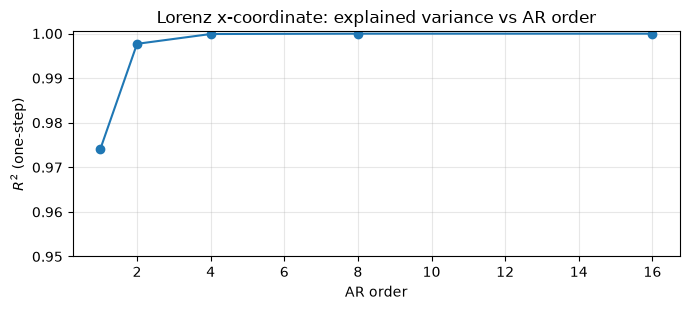

In [8]:
# --- univariate: AR order scan on the Lorenz x-coordinate --------------
orders = (1, 2, 4, 8, 16)
signal_var = lorenz_x.var()
scan_err, scan_r2 = [], []
print(f"{'order':>5} {'avg. forecast error':>20} {'R^2':>8}")
for ar_order in orders:
    fit = fit_ar_model(lorenz_x, ar_order)
    r2 = 1.0 - fit["forecast_errors"][0] ** 2 / signal_var
    scan_err.append(fit["average_forecast_error"])
    scan_r2.append(r2)
    print(f"{ar_order:>5} {fit['average_forecast_error']:>20.6f} {r2:>8.4f}")

fit1 = fit_ar_model(lorenz_x, 1)
print(f"\nAR(1): a1 = {fit1['coeffs'][0, 0, 0]:.4f}, "
      f"forecast error = {fit1['forecast_errors'][0]:.4f} "
      f"(signal std = {lorenz_x.std():.4f})")

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(orders, scan_r2, "o-", color="C0")
ax.set(xlabel="AR order", ylabel=r"$R^2$ (one-step)",
       title="Lorenz x-coordinate: explained variance vs AR order",
       ylim=(0.95, 1.0005))
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


An AR(1) model already explains ~97% of the variance of the Lorenz
x-coordinate (`a1 ≈ 0.99` — the sampled series is strongly autocorrelated).
Higher orders keep improving the fit substantially on this time grid
(AR(4): `R² ≈ 0.9999`) because the sampled trajectory is smooth; the
residuals shrink towards the integration noise floor of the Lorenz data.


fitted a1 = 0.8961 (true 0.9)
fitted forecast error = 0.9941 (true 1.0)
std: original = 2.240, simulated = 2.330, theoretical = 2.281


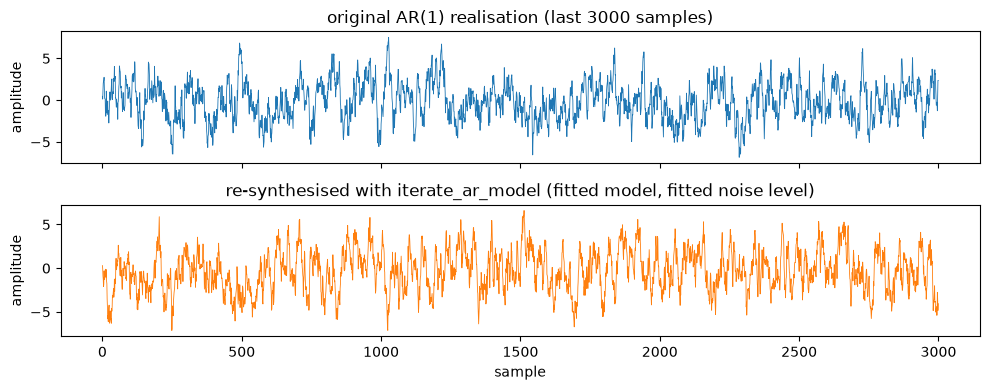

fitted level mean = 4.886 (true 5.0)


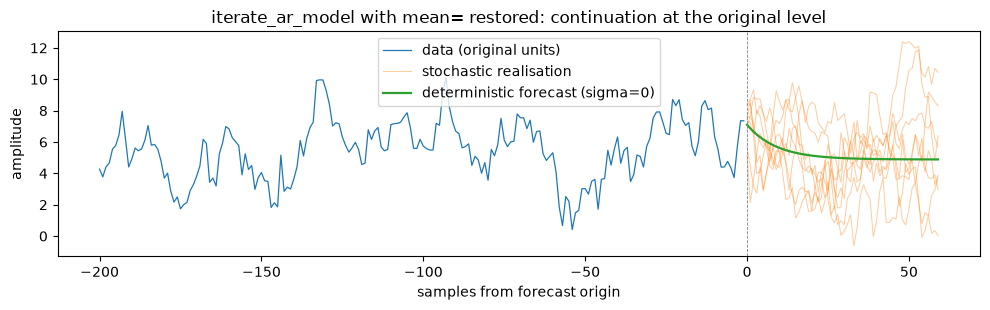

demeaned output : [2.208 1.979 1.773 1.589 1.424]
restored output : [7.094 6.865 6.659 6.475 6.31 ]  (== demeaned + mean)


In [9]:
# --- round trip: synthesise an AR(1) process, fit it, re-synthesise ----
rng = np.random.default_rng(1)
n = 20000
a_true = 0.9
e = rng.standard_normal(n)
ar1 = np.empty(n)
ar1[0] = e[0]
for k in range(1, n):
    ar1[k] = a_true * ar1[k - 1] + e[k]

fit_ar1 = fit_ar_model(ar1, 1)
print(f"fitted a1 = {fit_ar1['coeffs'][0, 0, 0]:.4f} (true {a_true})")
print(f"fitted forecast error = {fit_ar1['forecast_errors'][0]:.4f} "
      f"(true 1.0)")

sim = iterate_ar_model(fit_ar1["coeffs"], fit_ar1["forecast_errors"],
                       n_steps=3000, seed=7)
print(f"std: original = {ar1.std():.3f}, simulated = {sim[:, 0].std():.3f}, "
      f"theoretical = "
      f"{fit_ar1['forecast_errors'][0] / np.sqrt(1 - a_true ** 2):.3f}")

fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
axes[0].plot(ar1[-3000:], lw=0.6)
axes[0].set(ylabel="amplitude",
            title="original AR(1) realisation (last 3000 samples)")
axes[1].plot(sim[:, 0], lw=0.6, color="C1")
axes[1].set(xlabel="sample", ylabel="amplitude",
            title="re-synthesised with iterate_ar_model "
                  "(fitted model, fitted noise level)")
fig.tight_layout()
plt.show()

# --- continuation in original units: deterministic forecast + ensemble --
level = ar1 + 5.0                       # shift to a non-zero level
fit_level = fit_ar_model(level, 1)
hist = (level - fit_level["mean"])[-1:]  # model-domain (demeaned) history
print(f"fitted level mean = {fit_level['mean'][0]:.3f} (true 5.0)")

det = iterate_ar_model(fit_level["coeffs"], 0.0, n_steps=60, seed=0,
                       initial=hist, mean=fit_level["mean"])[:, 0]

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(np.arange(-200, 0), level[-200:], lw=0.9, label="data (original units)")
for b in range(8):
    st = iterate_ar_model(fit_level["coeffs"], fit_level["forecast_errors"],
                          n_steps=60, seed=20 + b, initial=hist,
                          mean=fit_level["mean"])[:, 0]
    ax.plot(np.arange(60), st, lw=0.7, color="C1", alpha=0.4,
            label="stochastic realisation" if b == 0 else None)
ax.plot(np.arange(60), det, lw=1.6, color="C2",
        label="deterministic forecast (sigma=0)")
ax.axvline(0.0, color="grey", ls="--", lw=0.6)
ax.set(xlabel="samples from forecast origin", ylabel="amplitude",
       title="iterate_ar_model with mean= restored: continuation at the "
             "original level")
ax.legend()
fig.tight_layout()
plt.show()

# without mean= the output stays demeaned (centred at 0)
raw = iterate_ar_model(fit_level["coeffs"], 0.0, n_steps=5, seed=0,
                       initial=hist)[:, 0]
restored = iterate_ar_model(fit_level["coeffs"], 0.0, n_steps=5, seed=0,
                            initial=hist, mean=fit_level["mean"])[:, 0]
print("demeaned output :", np.round(raw, 3))
print("restored output :", np.round(restored, 3),
      " (== demeaned + mean)")


fitted AR(2) coefficients: [ 0.6044 -0.4087] (true [0.6, -0.4])
forecast error: 0.9937 (innovation sigma = 1)


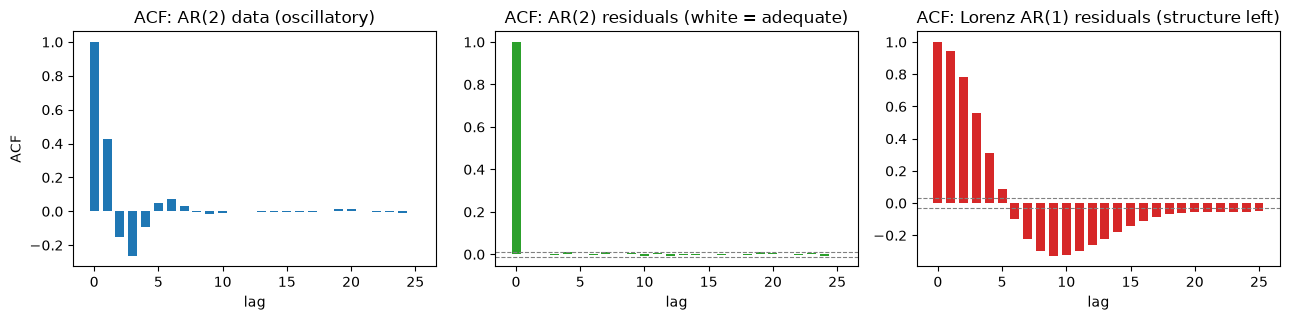

refit of a simulated AR(2): [ 0.5991 -0.4123] (true [0.6, -0.4])


In [10]:
# --- AR(2) synthetic: multi-lag coefficients and residual diagnostics ---
# An AR(2) process with complex roots (phi1 = 0.6, phi2 = -0.4) has an
# oscillatory ACF; fitting order 2 must recover both lag coefficients.
phi1, phi2 = 0.6, -0.4
n = 30000
rng = np.random.default_rng(3)
e = rng.standard_normal(n)
ar2 = np.empty(n)
ar2[:2] = e[:2]
for k in range(2, n):
    ar2[k] = phi1 * ar2[k - 1] + phi2 * ar2[k - 2] + e[k]

fit_ar2 = fit_ar_model(ar2, 2)
print("fitted AR(2) coefficients:",
      np.round(fit_ar2["coeffs"][0, 0], 4), f"(true [{phi1}, {phi2}])")
print("forecast error:", round(fit_ar2["forecast_errors"][0], 4),
      "(innovation sigma = 1)")

# Residual diagnostics: an adequate model leaves WHITE residuals.  The
# dashed lines are the 95% white-noise confidence band (~1.96/sqrt(N)).
# The AR(2) residuals sit inside the band; the Lorenz AR(1) residuals
# show a strong lag-1 correlation, i.e. exactly the linear structure the
# higher orders in the scan above remove.
max_lag = 25
lags = np.arange(max_lag + 1)


def white_band(residuals):
    return 1.96 / np.sqrt(len(residuals))


fig, axes = plt.subplots(1, 3, figsize=(13, 3.3))
axes[0].bar(lags, autocorrelation(ar2, max_lag=max_lag), width=0.7)
axes[0].set(title="ACF: AR(2) data (oscillatory)", xlabel="lag", ylabel="ACF")

r_white = autocorrelation(fit_ar2["residuals"][:, 0], max_lag=max_lag)
axes[1].bar(lags, r_white, width=0.7, color="C2")
b = white_band(fit_ar2["residuals"])
axes[1].axhline(b, color="grey", ls="--", lw=0.8)
axes[1].axhline(-b, color="grey", ls="--", lw=0.8)
axes[1].set(title="ACF: AR(2) residuals (white = adequate)", xlabel="lag")

r_lor = autocorrelation(fit1["residuals"][:, 0], max_lag=max_lag)
axes[2].bar(lags, r_lor, width=0.7, color="C3")
b = white_band(fit1["residuals"])
axes[2].axhline(b, color="grey", ls="--", lw=0.8)
axes[2].axhline(-b, color="grey", ls="--", lw=0.8)
axes[2].set(title="ACF: Lorenz AR(1) residuals (structure left)",
            xlabel="lag")
fig.tight_layout()
plt.show()

# round trip at order 2: re-synthesise and refit
sim2 = iterate_ar_model(fit_ar2["coeffs"], fit_ar2["forecast_errors"],
                        n_steps=n, seed=9)
refit2 = fit_ar_model(sim2[:, 0], 2)
print("refit of a simulated AR(2):", np.round(refit2["coeffs"][0, 0], 4),
      f"(true [{phi1}, {phi2}])")


AR(1) coupling matrix A (row d = predicted component):
[[ 6.930e-01  2.940e-01 -0.000e+00]
 [-3.350e-01  1.236e+00 -1.000e-03]
 [ 5.000e-03 -1.000e-02  9.630e-01]]
individual forecast errors: [0.193 1.464 2.326]
spectral radius: 0.977
component means (z is far from zero!): [-0.93 -0.93 23.61]


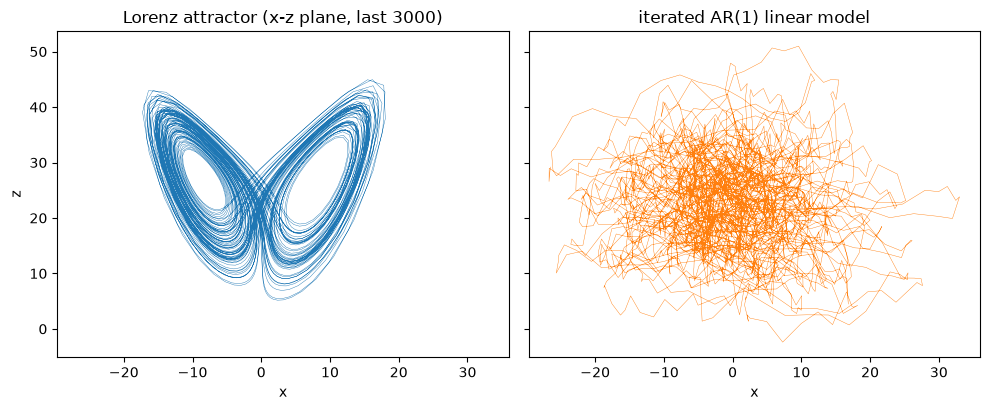

In [11]:
# --- multivariate: AR(1) model of the full Lorenz trajectory -----------
fit3 = fit_ar_model(lor, 1)              # lor: (N, 3) Lorenz x/y/z
A = fit3["coeffs"][:, :, 0]              # one-step coupling matrix (3, 3)
print("AR(1) coupling matrix A (row d = predicted component):")
print(np.round(A, 3))
print("individual forecast errors:", np.round(fit3["forecast_errors"], 3))
print("spectral radius:", round(np.abs(np.linalg.eigvals(A)).max(), 3))
print("component means (z is far from zero!):",
      np.round(fit3["mean"], 2))

# mean= restores the original Lorenz coordinates; without it the simulated
# orbit would be centred at the origin and sit at the wrong height.
sim3 = iterate_ar_model(fit3["coeffs"], fit3["forecast_errors"],
                        n_steps=3000, seed=11, mean=fit3["mean"])

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharex=True, sharey=True)
axes[0].plot(lor[-3000:, 0], lor[-3000:, 2], lw=0.3)
axes[0].set(title="Lorenz attractor (x-z plane, last 3000)",
            xlabel="x", ylabel="z")
axes[1].plot(sim3[:, 0], sim3[:, 2], lw=0.3, color="C1")
axes[1].set(title="iterated AR(1) linear model", xlabel="x")
fig.tight_layout()
plt.show()


The fitted one-step coupling matrix is strongly diagonal (each component is
mostly predicted by its own past) but shows real cross-coupling between the
x and y coordinates. Its spectral radius ≈ 0.98 < 1, so the iterated linear
model is stable: it oscillates on a ring of roughly the right size in the
x-z plane, but being linear it cannot reproduce the chaotic butterfly — AR
models capture the autocorrelation structure, not the nonlinear dynamics.


## 5. `notch_filter` / `wiener_filter` / `low121` / `savitzky_golay` — linear filters

Four small filters that all return a series the same length as the input:

- **`notch_filter(series, freq, q=30, fs=1)`** — a zero-phase biquad
  notch that removes a single narrow-band frequency (mains hum, a clock
  line); `q` sets the notch sharpness.
- **`wiener_filter(series, noise_var)`** — the frequency-domain
  (non-causal) Wiener filter: each FFT bin is kept in proportion to its
  estimated signal power.
- **`low121(series)`** — one pass of the binomial `[1, 2, 1] / 4`
  three-tap smoother; preserves constant and linear sequences exactly.
- **`savitzky_golay(series, window, order, deriv=0)`** — fits a local
  polynomial of degree `order` over an odd `window`; with `deriv > 0` it
  returns a smoothed numerical derivative (per sample).


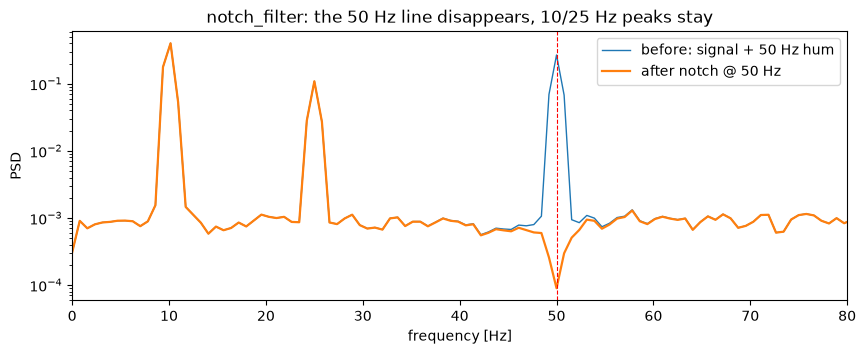

In [12]:
# --- notch_filter: remove a 50 Hz mains-style interference line ---------
hummy = x + 0.8 * np.sin(2 * np.pi * 50.0 * t)
dehummed = notch_filter(hummy, freq=50.0, q=30.0, fs=fs)

f_h, p_h = power_spectrum(hummy, method='welch', fs=fs)
f_d, p_d = power_spectrum(dehummed, method='welch', fs=fs)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.semilogy(f_h, p_h, lw=1.0, label='before: signal + 50 Hz hum')
ax.semilogy(f_d, p_d, lw=1.6, label='after notch @ 50 Hz')
ax.axvline(50.0, color='r', ls='--', lw=0.8)
ax.set(xlabel='frequency [Hz]', ylabel='PSD', xlim=(0, 80),
       title='notch_filter: the 50 Hz line disappears, 10/25 Hz peaks stay')
ax.legend()
plt.show()


The notch suppresses the 50 Hz line by more than 40 dB while the 10 Hz
and 25 Hz signal peaks are untouched.  Filtering is applied forward *and*
backward (`filtfilt`), so no phase delay is introduced.  A larger quality
factor `q` makes the rejected band narrower; a smaller `q` damps a wider
range around the target frequency.


MSE before: 0.2515, after Wiener: 0.0603


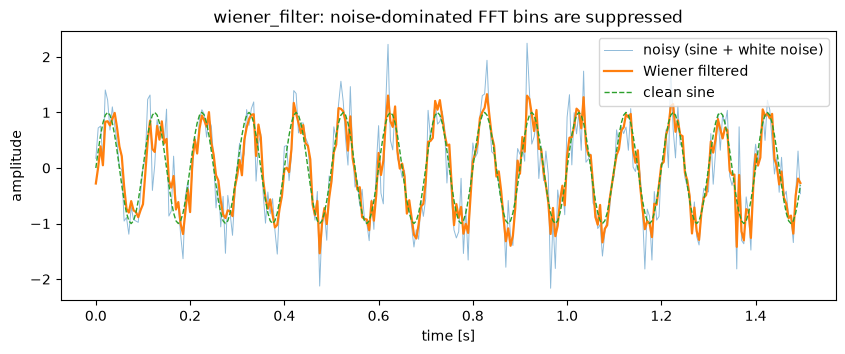

In [13]:
# --- wiener_filter: frequency-domain denoising --------------------------
rng_f = np.random.default_rng(1)
tone = np.sin(2 * np.pi * 10.0 * t)
noisy_f = tone + 0.5 * rng_f.standard_normal(N)
denoised_f = wiener_filter(noisy_f, noise_var=0.5 ** 2)

mse_before = np.mean((noisy_f - tone) ** 2)
mse_after = np.mean((denoised_f - tone) ** 2)
print(f'MSE before: {mse_before:.4f}, after Wiener: {mse_after:.4f}')

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(t[:300], noisy_f[:300], lw=0.7, alpha=0.5, label='noisy (sine + white noise)')
ax.plot(t[:300], denoised_f[:300], lw=1.6, label='Wiener filtered')
ax.plot(t[:300], tone[:300], ls='--', lw=1.0, label='clean sine')
ax.set(xlabel='time [s]', ylabel='amplitude',
       title='wiener_filter: noise-dominated FFT bins are suppressed')
ax.legend()
plt.show()


With the true noise variance the MSE against the clean tone drops by
roughly a factor of four.  `noise_var=0` returns the input unchanged,
while a very large value suppresses every bin (output ~ 0); the mean (DC
bin) is effectively kept because its bin power dominates the spectrum.


### Smoothing: `low121` versus `savitzky_golay`

`low121` is the simplest possible low-pass (one `[1, 2, 1] / 4` pass);
the Savitzky-Golay filter fits local polynomials and preserves the shape
of broad-band features much better.  Both keep the sample count unchanged.


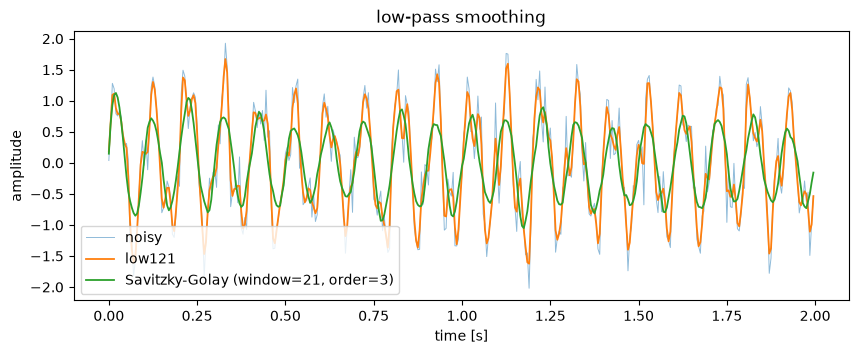

In [14]:
# --- low121 and Savitzky-Golay smoothing of the noisy test signal --------
seg = slice(0, 400)
sm_121 = low121(x)
sm_sg = savitzky_golay(x, window=21, order=3)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(t[seg], x[seg], lw=0.7, alpha=0.5, label='noisy')
ax.plot(t[seg], sm_121[seg], lw=1.3, label='low121')
ax.plot(t[seg], sm_sg[seg], lw=1.3, label='Savitzky-Golay (window=21, order=3)')
ax.set(xlabel='time [s]', ylabel='amplitude', title='low-pass smoothing')
ax.legend()
plt.show()


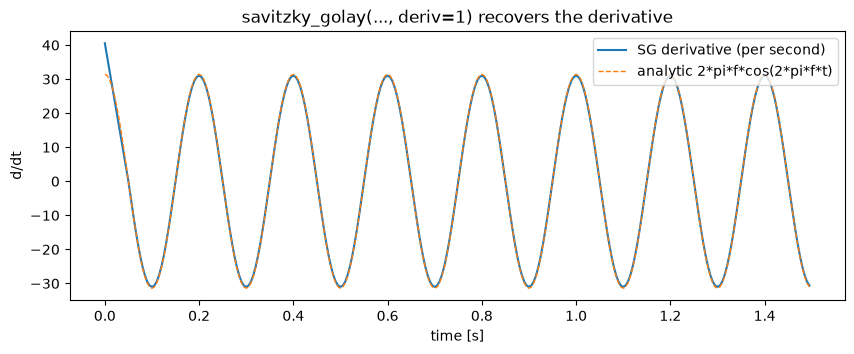

In [15]:
# --- savitzky_golay with deriv=1: smoothed numerical derivative ---------
phase = 2 * np.pi * 5.0 * t          # 5 Hz sine, t in seconds
wave = np.sin(phase)
# deriv=1 gives the slope per sample; multiply by fs to get per-second units
rate = savitzky_golay(wave, window=21, order=3, deriv=1) * fs

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(t[:300], rate[:300], lw=1.5, label='SG derivative (per second)')
ax.plot(t[:300], 2 * np.pi * 5.0 * np.cos(phase[:300]), ls='--', lw=1.0,
        label='analytic 2*pi*f*cos(2*pi*f*t)')
ax.set(xlabel='time [s]', ylabel='d/dt',
       title='savitzky_golay(..., deriv=1) recovers the derivative')
ax.legend()
plt.show()


## 6. `fit_arima` / `iterate_arima_model` — ARIMA / ARMA modelling

`fit_arima(series, poles=10, ar_order=0, diff_order=0, ma_order=0,
max_iter=50, convergence=1e-3)` is the Python port of `arima-model`.
It works on the `diff_order`-th difference of the input (the **I** step; the
helper `difference(series, d)` does the same standalone) with per-component
means subtracted, and always starts from an AR fit of order `poles`.  When
`ar_order + ma_order > 0` the fit is refined by the Hannan-Rissanen scheme:
the residuals of the previous pass enter the regression as lagged-innovation
(**MA**) regressors, and the iteration is repeated until the residual RMS
change falls below `convergence`:

    y_d(t) = sum_(i,j) a_(d,i,j) * y_i(t-1-j)
           + sum_(i,j) m_(d,i,j) * e_i(t-1-j) + e_d(t)

The result dict contains `coeffs` of shape `(dim, size)` (column order given
by `regressors`, rows `[kind, source, lag]`: `kind = 0` is a lagged data term
`x_source(n-1-lag)`, `kind = 1` a lagged innovation term
`e_(source-dim)(n-1-lag)`), plus `residuals`, `forecast_errors`,
`log_likelihood`, `aic` (with `k = ar_order + ma_order`, or `poles` in
pure-AR mode), `n_iterations` and the convergence traces.  It also records
`diff_order` and `diff_anchors` (the last observed point of each difference
level; row 0 is the end of the original series), which are needed to bring
simulations back to the original units.

`iterate_arima_model(fit, n_steps, seed=..., initial=...)` re-synthesises
data from a fitted model.  Unlike `iterate_ar_model` it drives the recursion
with innovations **resampled from the fitted residuals** (a bootstrap, the
equivalent of `rand_arb_dist`), so no Gaussianity is assumed.  The
raw output lives in the model domain (differenced and mean-subtracted); pass
`restore_level=True` to add the mean back and invert the differencing
(cumulative sums anchored at the observed end of the series), so the result
is in the original units and continues seamlessly from the fitted data.
The `initial` history must always be given in model-domain units — the last
`fit["poles"]` samples of `difference(series, d) - fit["mean"]` (or just
`series - fit["mean"]` when `d = 0`).


first differences (difference(walk[:7], 1)): [-0.811  0.142  1.047 -1.166 -2.177 -1.505]
ARIMA(1,1,0) fit: rho = 0.7535 (true 0.75), forecast error = 1.0024 (innovation sigma = 1)
naive AR(1) on the raw walk: a1 = 0.9997 (spurious unit root - differencing is required)


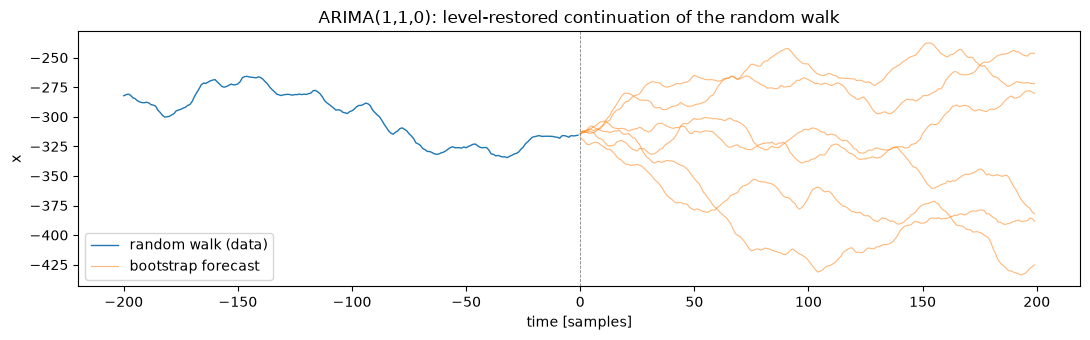

model-domain output (increments): [0.923 1.049 1.459]
restored levels:                  [-314.665 -313.656 -312.236]
check: walk[-1] + first restored increment = -314.665


In [16]:
# --- ARIMA(1,1,0): random walk with AR(1) increments --------------------
rng = np.random.default_rng(42)
rho = 0.75
inc = np.empty(8000)
inc[0] = rng.standard_normal()
for k in range(1, 8000):
    inc[k] = rho * inc[k - 1] + rng.standard_normal()
walk = np.cumsum(inc)                      # non-stationary level

print("first differences (difference(walk[:7], 1)):",
      np.round(difference(walk[:7], 1), 3))

fit_walk = fit_arima(walk, poles=10, ar_order=1, diff_order=1,
                     convergence=1e-4)
print(f"ARIMA(1,1,0) fit: rho = {fit_walk['coeffs'][0, 0]:.4f} "
      f"(true {rho}), forecast error = "
      f"{fit_walk['forecast_errors'][0]:.4f} (innovation sigma = 1)")

# fitting the manually differenced series gives the identical model
refit = fit_arima(difference(walk, 1), poles=10, ar_order=1,
                  convergence=1e-4)
np.testing.assert_allclose(fit_walk["coeffs"], refit["coeffs"], atol=1e-12)

# a naive AR(1) fit on the undifferenced walk only reports the unit root
fit_naive = fit_arima(walk, poles=1)
print(f"naive AR(1) on the raw walk: a1 = {fit_naive['coeffs'][0, 0]:.4f} "
      "(spurious unit root - differencing is required)")

# --- forecast the integrated series in its original units ---------------
# initial history must live in the model domain (differenced, then
# mean-subtracted); restore_level=True undifferences the simulation and
# anchors it at the last observation, so the forecast continues the walk.
dw = difference(walk, fit_walk["diff_order"])
init_walk = (dw - fit_walk["mean"])[-fit_walk["poles"]:]

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(np.arange(-200, 0), walk[-200:], lw=1.0, label="random walk (data)")
for b in range(6):
    fc = iterate_arima_model(fit_walk, n_steps=200, seed=100 + b,
                             initial=init_walk, restore_level=True)[:, 0]
    ax.plot(np.arange(200), fc, lw=0.8, color="C1", alpha=0.55,
            label="bootstrap forecast" if b == 0 else None)
ax.axvline(0.0, color="grey", ls="--", lw=0.6)
ax.set(xlabel="time [samples]", ylabel="x",
       title="ARIMA(1,1,0): level-restored continuation of the random walk")
ax.legend()
fig.tight_layout()
plt.show()

# model-domain output (differenced, demeaned increments) vs restored levels
raw_fc = iterate_arima_model(fit_walk, n_steps=3, seed=100,
                             initial=init_walk)
rest_fc = iterate_arima_model(fit_walk, n_steps=3, seed=100,
                              initial=init_walk, restore_level=True)
print("model-domain output (increments):", np.round(raw_fc[:, 0], 3))
print("restored levels:                 ", np.round(rest_fc[:, 0], 3))
print(f"check: walk[-1] + first restored increment = "
      f"{walk[-1] + raw_fc[0, 0] + fit_walk['mean'][0]:.3f}")


### ARMA refinement: the iterative `-P` stage

With `ar_order` / `ma_order` the initial AR fit is refined by regressing on
lagged data *and* lagged innovation estimates (Hannan-Rissanen).  Below, an
ARMA(1,1) series (`phi = 0.6`, `theta = 0.4`) is fitted and compared with
pure AR models of several orders through the AIC.  The two refinement
coefficients recover `(phi, theta)`, and the `regressors` table identifies
which column of `coeffs` is which.


In [17]:
# --- ARMA(1,1): pure AR order scan versus the iterative refinement ------
phi, theta = 0.6, 0.4
rng = np.random.default_rng(43)
burn = 200
e = rng.standard_normal(20000 + burn)
y_arma = np.empty(20000 + burn)
y_arma[0] = e[0]
for k in range(1, 20000 + burn):
    y_arma[k] = phi * y_arma[k - 1] + e[k] + theta * e[k - 1]
y_arma = y_arma[burn:]

print(f"{'model':<14} {'params':>6} {'avg fc err':>11} {'AIC':>12}")
for p in (2, 5, 10, 20):
    f = fit_arima(y_arma, poles=p)
    print(f"{f'AR({p})':<14} {p:>6} {f['average_forecast_error']:>11.5f} "
          f"{f['aic']:>12.2f}")

fit_arma = fit_arima(y_arma, poles=10, ar_order=1, ma_order=1,
                     convergence=1e-4)
print(f"{'ARMA(1,1)':<14} {2:>6} "
      f"{fit_arma['average_forecast_error']:>11.5f} "
      f"{fit_arma['aic']:>12.2f}")

print("\nrefinement coefficients (columns of coeffs):",
      np.round(fit_arma["coeffs"][0], 4), f"(true [{phi}, {theta}])")
print("regressors [kind, source, lag]:")
print(fit_arma["regressors"])
print("iterations:", fit_arma["n_iterations"])


model          params  avg fc err          AIC
AR(2)               2     1.00965     57145.52
AR(5)               5     1.00244     56864.96
AR(10)             10     1.00222     56866.17
AR(20)             20     1.00203     56878.79
ARMA(1,1)           2     1.00256     56863.95

refinement coefficients (columns of coeffs): [0.5895 0.4018] (true [0.6, 0.4])
regressors [kind, source, lag]:
[[0 0 0]
 [1 1 0]]
iterations: 8


### `iterate_arima_model` — bootstrapped realisation and continuation

`iterate_arima_model(fit, n_steps, seed)` draws innovations with replacement
from `fit["residuals"]` and runs the fitted recursion.  Re-fitting the
simulation recovers the model, and the ACF of the realisation matches the
data.  Passing `initial=` continues the observed series instead of starting
from a resampled history; it must be given in **model-domain units** — the
last `fit["poles"]` samples of `difference(series, d) - fit["mean"]` (oldest
row first), i.e. differenced and mean-subtracted.  `restore_level=True` then
converts the output back to the original series units: it adds the mean and,
for integrated models (`d > 0`), undifferences with cumulative sums anchored
at the end of the data, so the continuation starts exactly at the last
observation.


fitted  [phi, theta]: [0.5895 0.4018]
refit of simulation: [0.5914 0.4019]


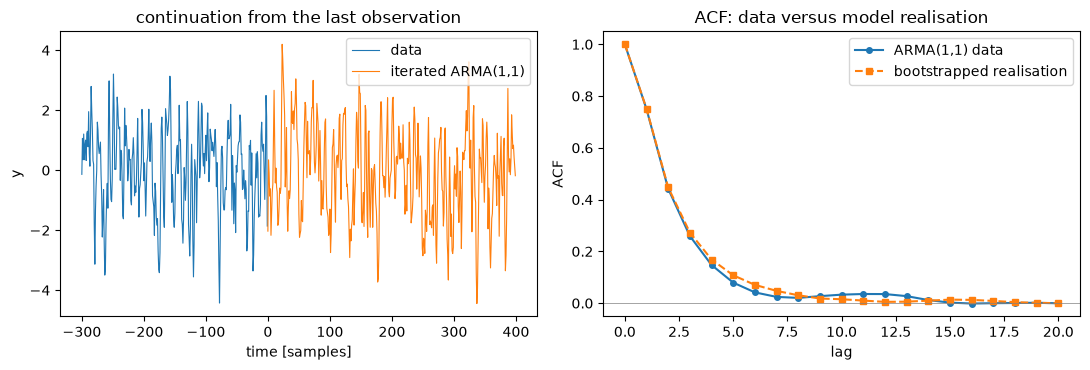

In [18]:
# --- bootstrapped realisation, refit and continuation --------------------
sim = iterate_arima_model(fit_arma, n_steps=10000, seed=7)
refit_sim = fit_arima(sim[:, 0], poles=10, ar_order=1, ma_order=1,
                      convergence=1e-4)
print("fitted  [phi, theta]:", np.round(fit_arma["coeffs"][0], 4))
print("refit of simulation:", np.round(refit_sim["coeffs"][0], 4))

# continuation: model-domain initial history; restore_level=True adds the
# mean back (d = 0 here; for integrated models it also undifferences, as in
# the ARIMA(1,1,0) example above).
init_arma = (y_arma - fit_arma["mean"])[-fit_arma["poles"]:]
cont = iterate_arima_model(fit_arma, n_steps=400, seed=8,
                           initial=init_arma, restore_level=True)[:, 0]

max_lag = 20
lags = np.arange(max_lag + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(np.arange(-300, 0), y_arma[-300:], lw=0.8, label="data")
axes[0].plot(np.arange(0, 400), cont, lw=0.8, color="C1",
             label="iterated ARMA(1,1)")
axes[0].set(xlabel="time [samples]", ylabel="y",
            title="continuation from the last observation")
axes[0].legend()
axes[1].plot(lags, autocorrelation(y_arma, max_lag=max_lag), "o-", ms=4,
             label="ARMA(1,1) data")
axes[1].plot(lags, autocorrelation(sim[:, 0], max_lag=max_lag), "s--",
             ms=4, label="bootstrapped realisation")
axes[1].axhline(0.0, color="grey", lw=0.5)
axes[1].set(xlabel="lag", ylabel="ACF",
            title="ACF: data versus model realisation")
axes[1].legend()
fig.tight_layout()
plt.show()


## Summary

- **`power_spectrum`** gives periodogram / Welch / raw-FFT power estimates,
  with frequencies in physical units when `fs` is given; Welch averaging is the
  smooth, low-variance workhorse and `nperseg` controls its resolution.
- **`mem_spectrum`** gives a smooth, high-resolution Burg-AR spectrum on a
  normalised `[0, 0.5)` cycles-per-sample grid (multiply by `fs` for Hz); the
  AR `order` controls smoothness versus spurious detail.
- **`autocorrelation`** gives the ACF (optionally normalised and detrended):
  oscillatory for periodic signals, essentially flat for white noise, and
  smoothly decaying for chaotic broadband signals such as Lorenz.
- **`fit_ar_model` / `iterate_ar_model`** fit a multivariate AR model by least squares and re-synthesise noise-driven realisations from it; the forecast error quantifies the linearly unexplained variance.
- **`fit_arima` / `iterate_arima_model`** : differencing (`diff_order`), an initial AR(`poles`) fit and an iterative Hannan-Rissanen ARMA refinement judged by the AIC; iteration resamples the fitted residuals (bootstrap) instead of assuming Gaussian noise.
- **`notch_filter`** removes a single narrow-band frequency (zero-phase,
  `q` controls the notch width), **`wiener_filter`** denoises by per-bin FFT
  attenuation from a known noise variance, **`low121`** gives a trivial
  `[1, 2, 1] / 4` smoothing pass, and **`savitzky_golay`** gives
  local-polynomial smoothing and derivatives (`deriv=1, 2, ...`).
